In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib

In [2]:
df=pd.read_csv("/content/train_data.csv")
df.head()

,Date,Petrol (USD)
0,6/9/2003,74.59
1,6/16/2003,74.47
2,6/23/2003,74.42
3,6/30/2003,74.35
4,7/7/2003,74.28


In [3]:
df.rename(columns={"Petrol (USD)":"Petrol"},inplace=True)

In [4]:
df.shape

(813, 2)

In [5]:
df.isnull().sum()

,0
Date,0
Petrol,2


In [6]:
mode=df["Petrol"].mode()[0]
df["Petrol"]=df["Petrol"].fillna(mode)

In [7]:
df.head()

,Date,Petrol
0,6/9/2003,74.59
1,6/16/2003,74.47
2,6/23/2003,74.42
3,6/30/2003,74.35
4,7/7/2003,74.28


In [8]:
new_df=df.copy()

In [9]:
df['Date'] = pd.to_datetime(df['Date'])  #

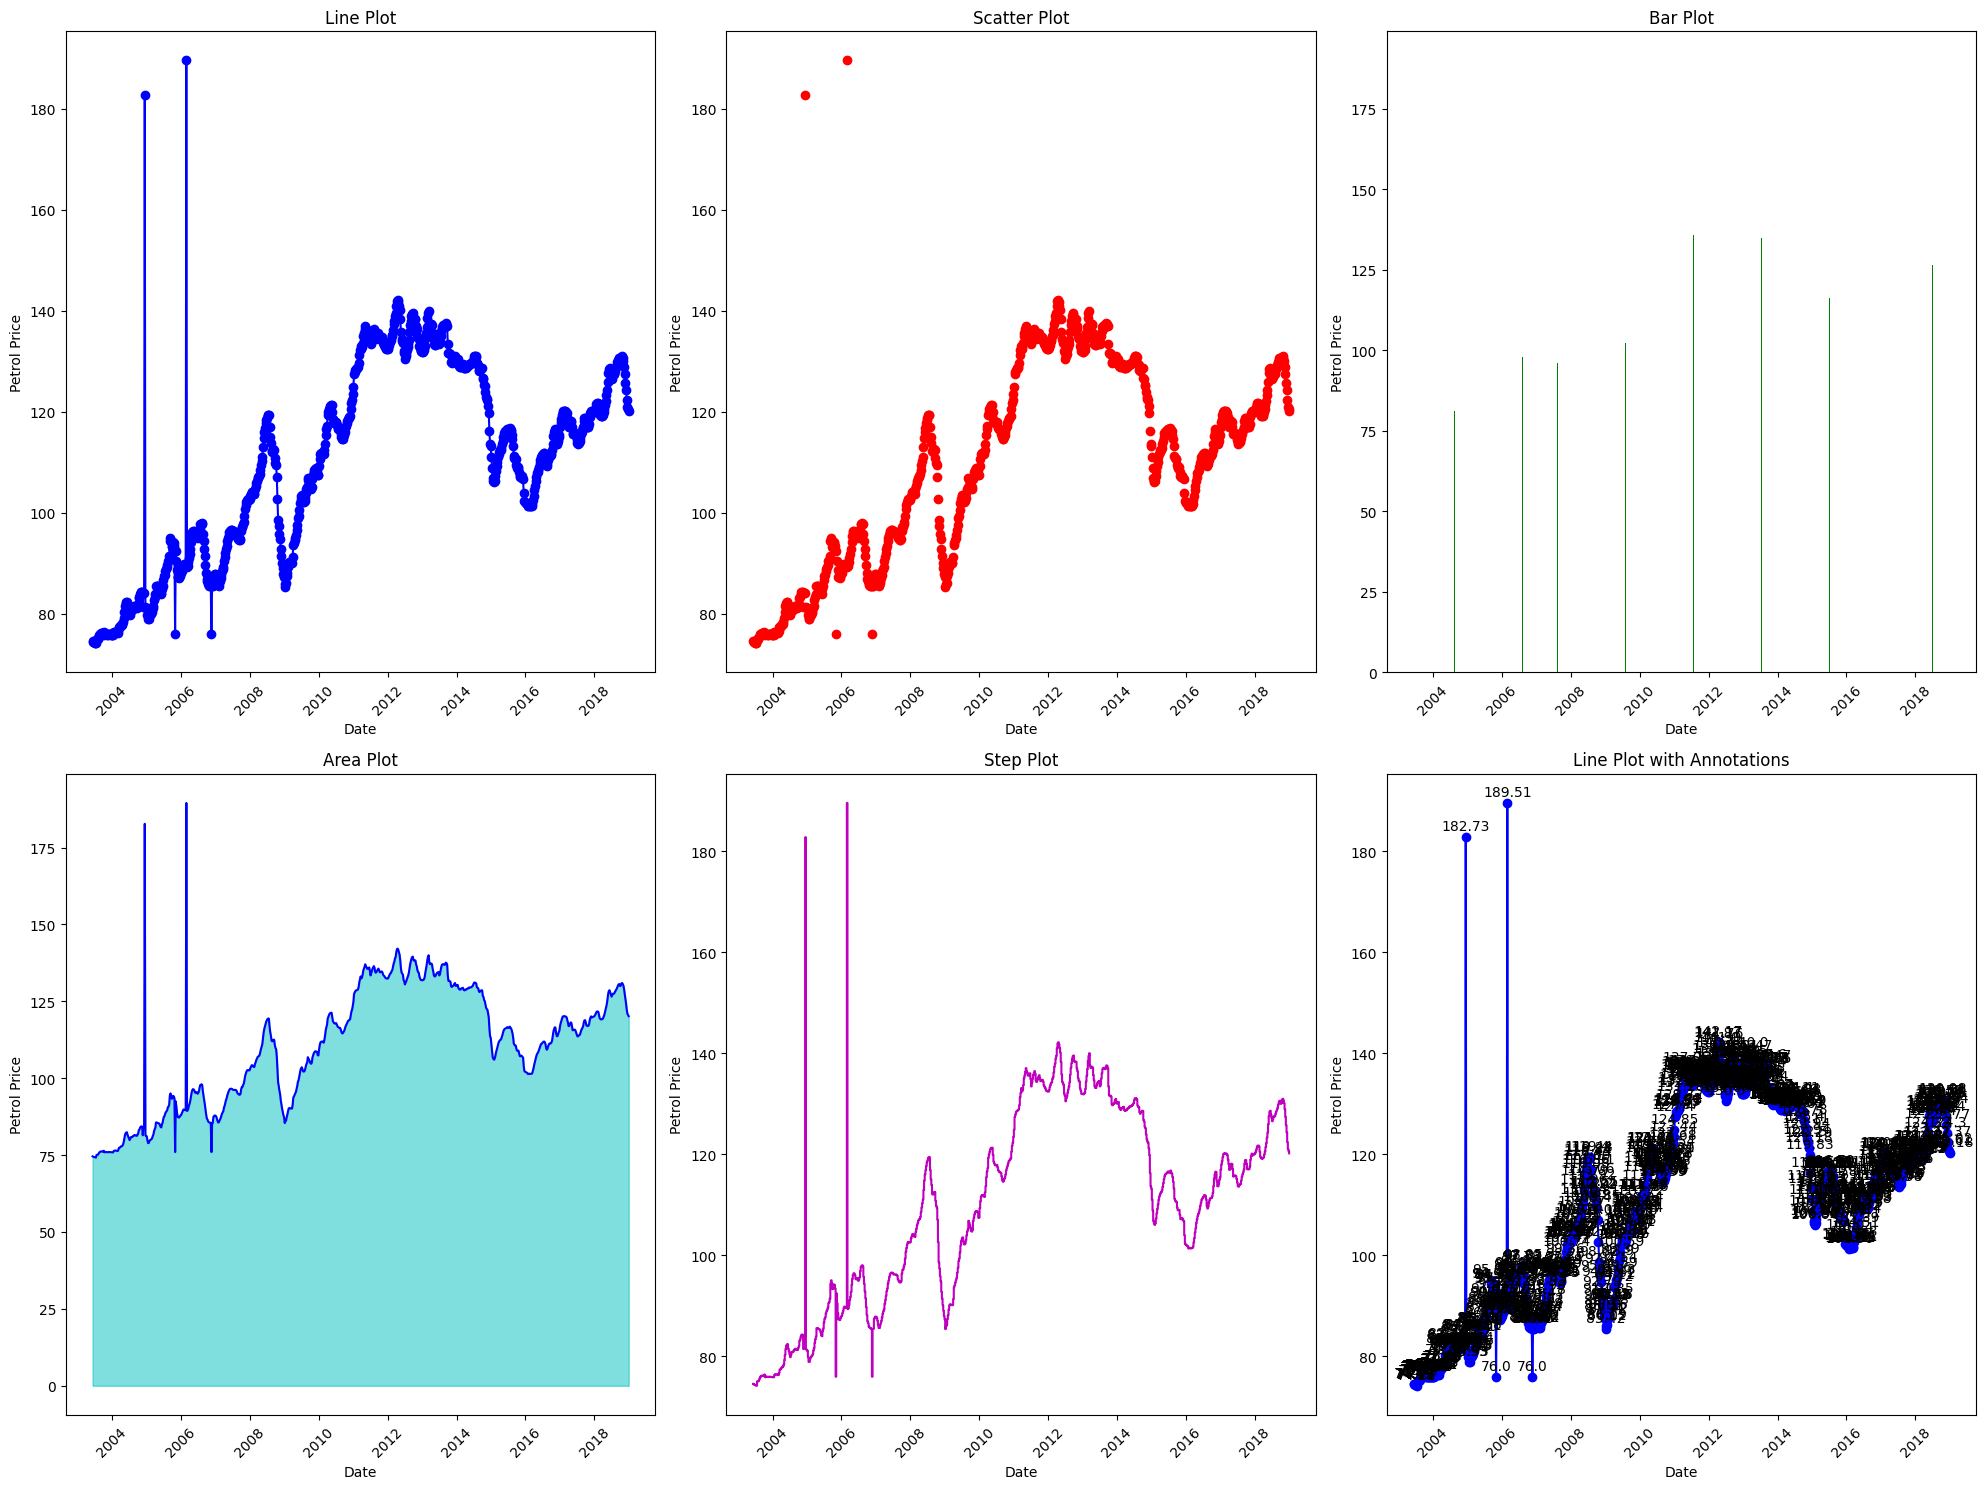

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()  # Flatten for easier iteration

# 1. Line Plot
axes[0].plot(df['Date'], df['Petrol'], marker='o', linestyle='-', color='b')
axes[0].set_title('Line Plot')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Petrol Price')
axes[0].tick_params(axis='x', rotation=45)

# 2. Scatter Plot
axes[1].scatter(df['Date'], df['Petrol'], color='r')
axes[1].set_title('Scatter Plot')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Petrol Price')
axes[1].tick_params(axis='x', rotation=45)

# 3. Bar Plot
axes[2].bar(df['Date'], df['Petrol'], color='g', width=0.1)
axes[2].set_title('Bar Plot')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Petrol Price')
axes[2].tick_params(axis='x', rotation=45)

# 4. Area Plot
axes[3].fill_between(df['Date'], df['Petrol'], color='c', alpha=0.5)
axes[3].plot(df['Date'], df['Petrol'], color='b')  # Add line for clarity
axes[3].set_title('Area Plot')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('Petrol Price')
axes[3].tick_params(axis='x', rotation=45)

# 5. Step Plot
axes[4].step(df['Date'], df['Petrol'], where='post', color='m')
axes[4].set_title('Step Plot')
axes[4].set_xlabel('Date')
axes[4].set_ylabel('Petrol Price')
axes[4].tick_params(axis='x', rotation=45)

# 6. Line Plot with Annotations
axes[5].plot(df['Date'], df['Petrol'], marker='o', linestyle='-', color='b')
for i, txt in enumerate(df['Petrol']):
    axes[5].annotate(f'{txt}', (df['Date'][i], df['Petrol'][i]), textcoords="offset points", xytext=(0,5), ha='center')
axes[5].set_title('Line Plot with Annotations')
axes[5].set_xlabel('Date')
axes[5].set_ylabel('Petrol Price')
axes[5].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

In [11]:
df.head()

,Date,Petrol
0,2003-06-09,74.59
1,2003-06-16,74.47
2,2003-06-23,74.42
3,2003-06-30,74.35
4,2003-07-07,74.28


In [12]:
df.drop(columns=["Date"],axis=1,inplace=True)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df=np.array(df).reshape(-1,1)
df=scaler.fit_transform(df)

In [14]:
df[: 10]

array([[0.00329575],
       [0.00225499],
       [0.00182134],
       [0.00121422],
       [0.00060711],
       [0.        ],
       [0.0074588 ],
       [0.00771899],
       [0.00789245],
       [0.01066782]])

In [15]:
train_size=int(len(df)*0.70)
test_size=len(df)-train_size
train_data,test_data=df[0:train_size,:],df[train_size:len(df),:]

In [16]:
train_data.shape,test_data.shape

((569, 1), (244, 1))

In [17]:
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        dataX.append(dataset[i:(i + time_step), 0])
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam

# Define model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))

# Compile with Adam optimizer and custom learning rate
learning_rate = 0.001  # set your desired learning rate
optimizer = Adam(learning_rate=learning_rate)
model.compile(loss='mean_squared_error', optimizer=optimizer)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history=model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=50,batch_size=64,verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 434ms/step - loss: 0.1214 - val_loss: 0.0099
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 0.0149 - val_loss: 0.0079
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0106 - val_loss: 8.1690e-04
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0061 - val_loss: 8.1091e-04
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0049 - val_loss: 7.5070e-04
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 0.0035 - val_loss: 7.9813e-04
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - loss: 0.0026 - val_loss: 8.4520e-04
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 0.0039 - val_loss: 7.4786e-04
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.0023 - val_loss: 7.7956e-04
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 0.0034 - val_loss: 0.0010
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/

In [20]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse transform to original scale
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_test_pred_inv = scaler.inverse_transform(y_test_pred)
original_data = scaler.inverse_transform(df)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


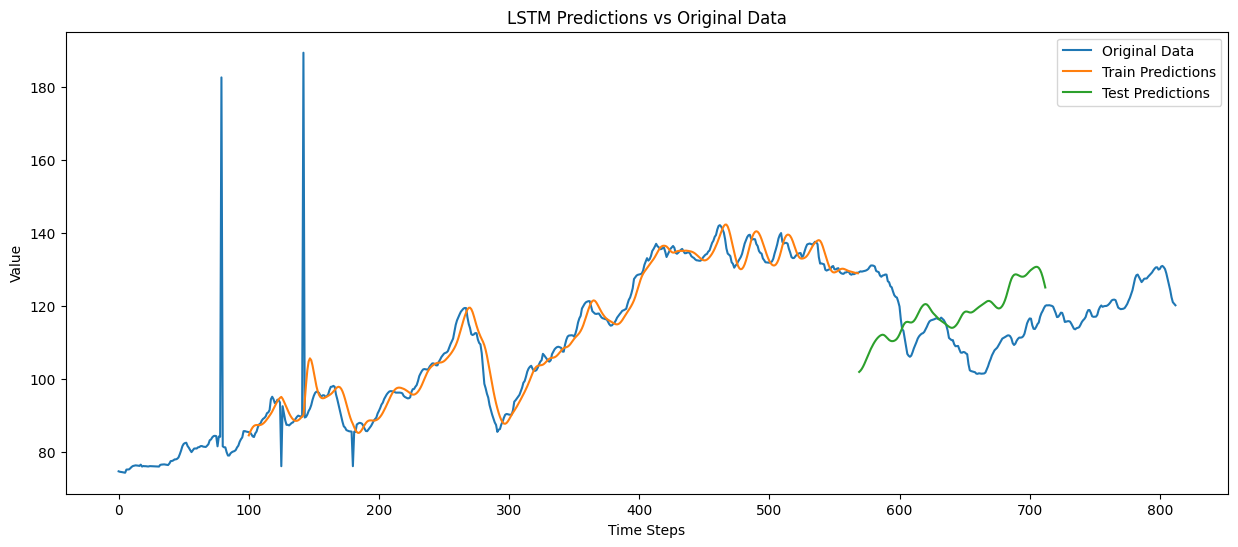

In [21]:
look_back = 100

train_plot = np.empty_like(df)
train_plot[:] = np.nan
train_plot[look_back:look_back+len(y_train_pred_inv), :] = y_train_pred_inv

test_plot = np.empty_like(df)
test_plot[:] = np.nan
start_idx = look_back + len(y_train_pred_inv)
end_idx = start_idx + len(y_test_pred_inv)
test_plot[start_idx:end_idx, :] = y_test_pred_inv

# Plot baseline and predictions
plt.figure(figsize=(15,6))
plt.plot(original_data, label='Original Data')
plt.plot(train_plot, label='Train Predictions')
plt.plot(test_plot, label='Test Predictions')
plt.title('LSTM Predictions vs Original Data')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

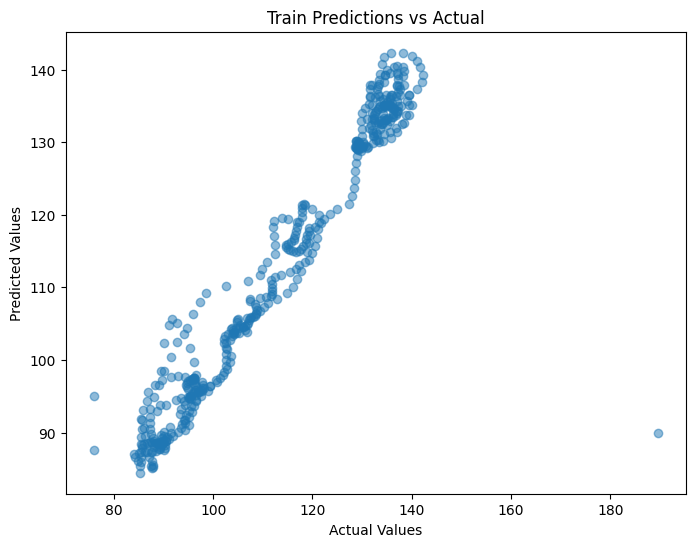

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(original_data[look_back:len(y_train_pred_inv)+look_back], y_train_pred_inv, alpha=0.5)
plt.title('Train Predictions vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

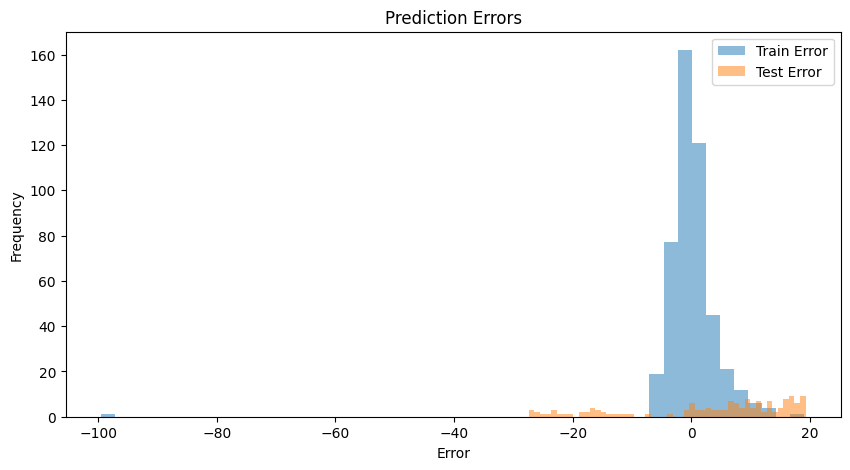

In [23]:
# Compute train and test errors
train_error = y_train_pred_inv - original_data[look_back:look_back+len(y_train_pred_inv)]

test_start_idx = look_back + len(y_train_pred_inv)
test_end_idx = test_start_idx + len(y_test_pred_inv)
test_error = y_test_pred_inv - original_data[test_start_idx:test_end_idx]

# Plot error histograms
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(train_error, bins=50, alpha=0.5, label='Train Error')
plt.hist(test_error, bins=50, alpha=0.5, label='Test Error')
plt.title('Prediction Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()


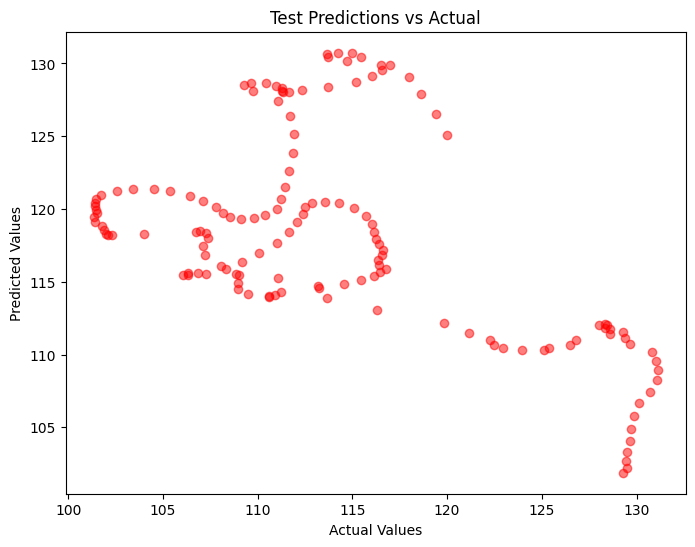

In [24]:
test_start_idx = look_back + len(y_train_pred_inv)
test_end_idx = test_start_idx + len(y_test_pred_inv)

# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(original_data[test_start_idx:test_end_idx], y_test_pred_inv, alpha=0.5, color='red')
plt.title('Test Predictions vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# Using ARIMA

In [25]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt
from pandas import read_csv
from matplotlib import pyplot
from datetime import datetime

from sklearn.metrics import mean_squared_error
from math import sqrt

In [26]:
df=pd.read_csv("/content/train_data.csv")
df.head()

,Date,Petrol (USD)
0,6/9/2003,74.59
1,6/16/2003,74.47
2,6/23/2003,74.42
3,6/30/2003,74.35
4,7/7/2003,74.28


In [27]:
df.dropna(inplace=True)

In [28]:
df.drop(columns=["Date"],axis=1,inplace=True)

In [29]:
df.rename(columns={"Petrol (USD)":"Petrol"},inplace=True)

In [30]:
df.head()

,Petrol
0,74.59
1,74.47
2,74.42
3,74.35
4,74.28


In [31]:
model = ARIMA(df["Petrol"].values, order=(5, 1, 0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)
forecast_df = pd.DataFrame(forecast, columns=['Forecast'])
print(forecast_df)

      Forecast
0   121.630850
1   121.349981
2   121.163503
3   121.073070
4   121.085003
5   121.115351
6   121.176273
7   121.145925
8   121.132746
9   121.130435
10  121.134632
11  121.137788
12  121.139218
13  121.136762
14  121.136175
15  121.136399
16  121.136809
17  121.136942
18  121.136884
19  121.136730
20  121.136730
21  121.136766
22  121.136791
23  121.136789
24  121.136779
25  121.136772
26  121.136775
27  121.136778
28  121.136779
29  121.136778
